# Colab vs 2HDMC clean discrepancy analysis

This is not a lambda drift analysis. Focus is channel/configuration discrepancy.

In [2]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
root = Path.cwd()
candidate = root/'scripts/out/refactor_colab_compare/real_run'
if not candidate.exists():
    candidate = root.parent/'scripts/out/refactor_colab_compare/real_run'
BASE = candidate
FIG_DIR = BASE.parent/'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
merged=pd.read_csv(BASE/'colab_vs_2hdmc_merged_comparison.csv')
width_stats=pd.read_csv(BASE/'width_rel_stats.csv')
grouped=pd.read_csv(BASE/'grouped_error_by_l1_l6_tb.csv')
print(len(merged), int(merged['set_param_ok'].sum()), int(merged['triple_ok'].sum()), int(merged['warning_flag'].sum()))
print('warning_flag caveat: not automatic physics veto')
df=merged[merged['triple_ok']==True].copy() if 'triple_ok' in merged.columns else merged.copy()


2400 2400 1600 2400
warning_flag caveat: not automatic physics veto


,channel,mean_rel,median_rel,max_rel
0,gg,0.679692,0.691368,0.703851
1,cc,0.239348,0.241029,0.260498
2,gaga,0.206853,0.192646,0.429884
4,Zga,0.079420,0.089502,0.106525
5,bb,0.061044,0.059988,0.078449
3,total,0.080088,0.019102,0.270761
6,tautau,0.001817,0.001817,0.001817


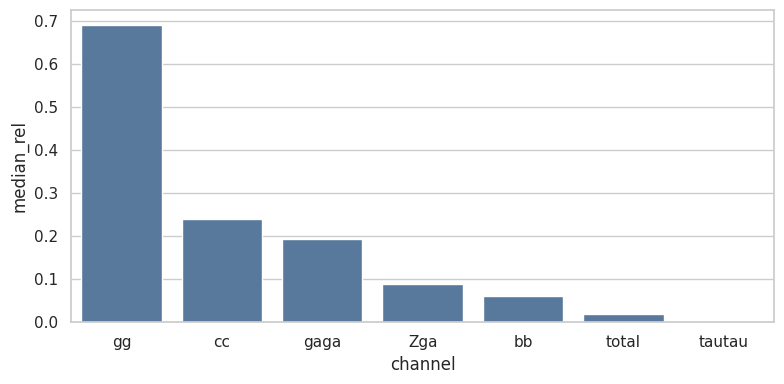

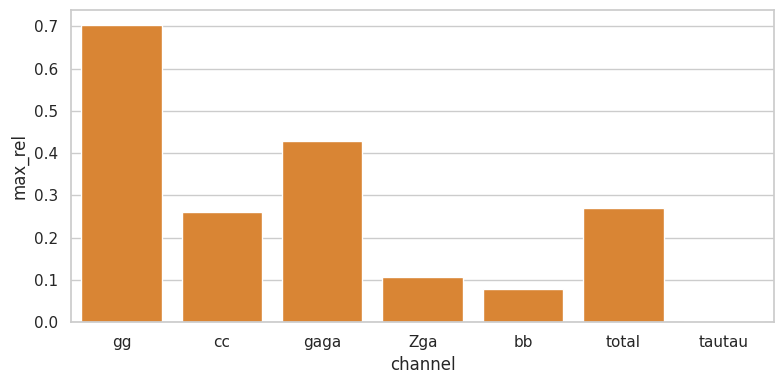

In [3]:
ordered=width_stats.sort_values('median_rel',ascending=False)
plt.figure(figsize=(8,4)); sns.barplot(data=ordered,x='channel',y='median_rel',color='#4C78A8'); plt.tight_layout(); plt.savefig(FIG_DIR/'channel_median_rel_errors.png',dpi=160)
plt.figure(figsize=(8,4)); sns.barplot(data=ordered,x='channel',y='max_rel',color='#F58518'); plt.tight_layout(); plt.savefig(FIG_DIR/'channel_max_rel_errors.png',dpi=160)
ordered[['channel','mean_rel','median_rel','max_rel']]

,lambda1,lambda6,tan_beta,n,median_rel_gg,median_rel_gaga,median_rel_total
0,0.4,0.01,10000.0,400,0.691368,0.391493,0.142481
2,1.0,0.01,10000.0,400,0.691368,0.371986,0.142053
1,0.4,0.10,10000.0,400,0.691368,0.029476,0.017041
3,1.0,0.10,10000.0,400,0.691368,0.028222,0.016098


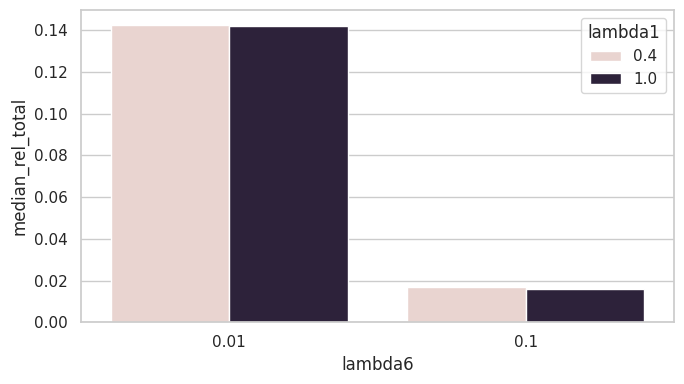

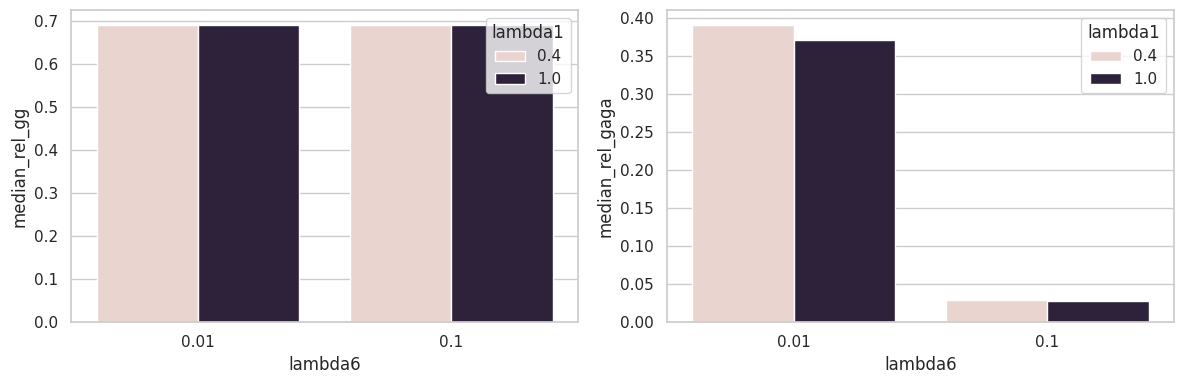

In [4]:
show=grouped.sort_values('median_rel_total',ascending=False)
plt.figure(figsize=(7,4)); sns.barplot(data=show,x='lambda6',y='median_rel_total',hue='lambda1'); plt.tight_layout(); plt.savefig(FIG_DIR/'grouped_config_median_rel_total.png',dpi=160)
fig,ax=plt.subplots(1,2,figsize=(12,4)); sns.barplot(data=show,x='lambda6',y='median_rel_gg',hue='lambda1',ax=ax[0]); sns.barplot(data=show,x='lambda6',y='median_rel_gaga',hue='lambda1',ax=ax[1]); plt.tight_layout(); plt.savefig(FIG_DIR/'grouped_config_median_rel_gg_gaga.png',dpi=160)
show[['lambda1','lambda6','tan_beta','n','median_rel_gg','median_rel_gaga','median_rel_total']]

tautau median 0.00181659157025015


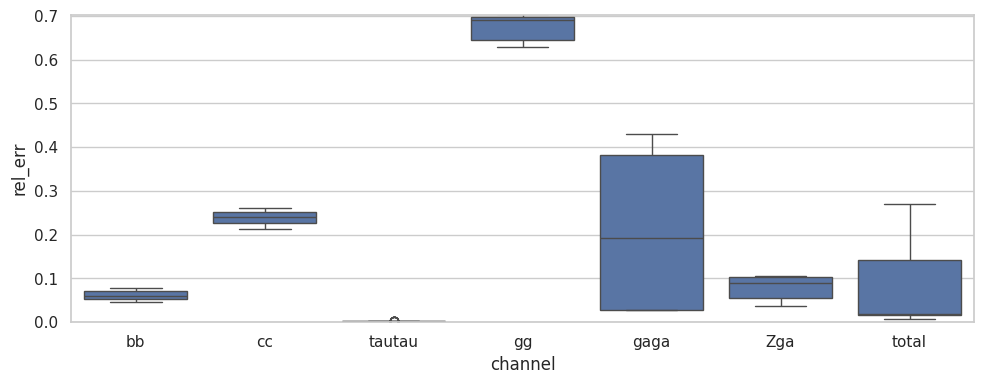

In [5]:
long_cols=[c for c in ['rel_err_width_bb','rel_err_width_cc','rel_err_width_tautau','rel_err_width_gg','rel_err_width_gaga','rel_err_width_Zga','rel_err_width_total'] if c in df.columns]
long=df[long_cols].melt(var_name='channel',value_name='rel_err'); long['channel']=long['channel'].str.replace('rel_err_width_','',regex=False)
plt.figure(figsize=(10,4)); sns.boxplot(data=long,x='channel',y='rel_err'); plt.ylim(0,np.nanpercentile(long['rel_err'],99.5)); plt.tight_layout()
print('tautau median', float(df['rel_err_width_tautau'].median()))

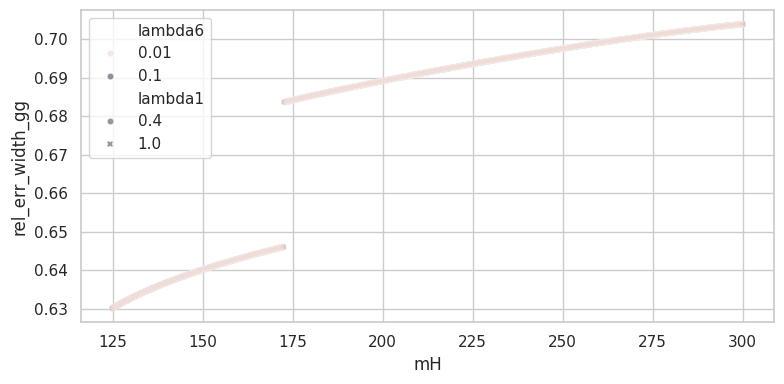

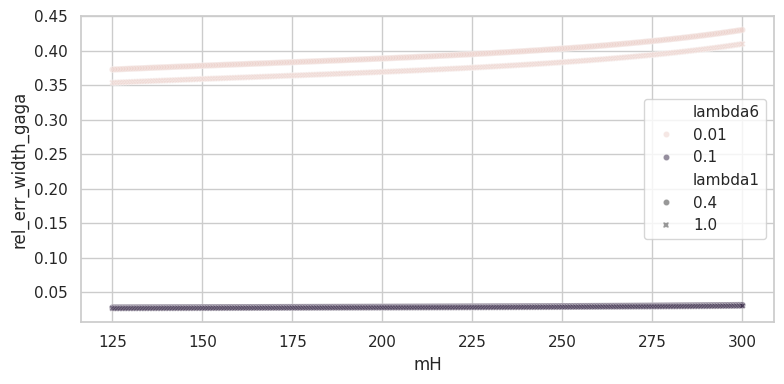

In [6]:
plt.figure(figsize=(8,4)); sns.scatterplot(data=df,x='mH',y='rel_err_width_gg',hue='lambda6',style='lambda1',alpha=0.5,s=20); plt.tight_layout(); plt.savefig(FIG_DIR/'mH_vs_rel_err_gg.png',dpi=160)
plt.figure(figsize=(8,4)); sns.scatterplot(data=df,x='mH',y='rel_err_width_gaga',hue='lambda6',style='lambda1',alpha=0.5,s=20); plt.tight_layout(); plt.savefig(FIG_DIR/'mH_vs_rel_err_gaga.png',dpi=160)

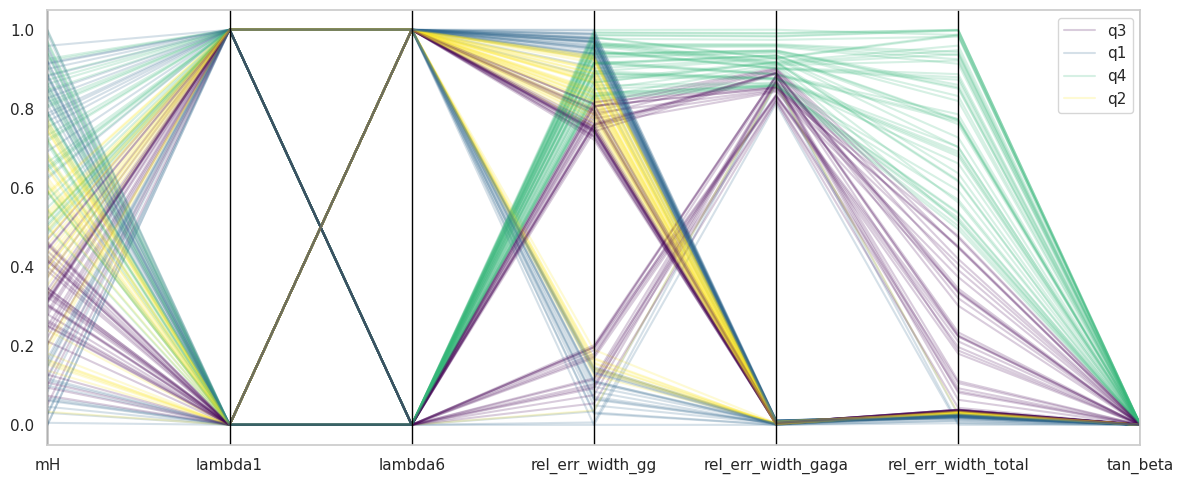

In [7]:
from pandas.plotting import parallel_coordinates

cols=['mH','lambda1','lambda6','rel_err_width_gg','rel_err_width_gaga','rel_err_width_total', 'tan_beta']
sub=df[cols].sample(min(200,len(df)),random_state=42).copy(); sub['color_bin']=pd.qcut(sub['rel_err_width_total'],q=4,labels=['q1','q2','q3','q4'])

for c in cols:
 v=sub[c].astype(float); d=v.max()-v.min(); sub[c]=0.0 if d==0 else (v-v.min())/d

plt.figure(figsize=(12,5)); parallel_coordinates(sub[['color_bin']+cols],'color_bin',colormap='viridis',alpha=0.2); plt.tight_layout(); plt.savefig(FIG_DIR/'parallel_hyperparams_errors.png',dpi=160)

In [9]:
top_cols=[c for c in ['mH','lambda1','lambda6','tan_beta','rel_err_width_gg','rel_err_width_gaga','rel_err_width_Zga','rel_err_width_total','width_gg','width_gg_colab','total_width','total_width_colab'] if c in df.columns]

# top 20 worst points by total relative error, to inspect for patterns
df.sort_values('rel_err_width_gg',ascending=False)[top_cols].head(20)

,mH,lambda1,lambda6,tan_beta,rel_err_width_gg,rel_err_width_gaga,rel_err_width_Zga,rel_err_width_total,width_gg,width_gg_colab,total_width,total_width_colab
1999,300.000000,1.0,0.01,10000.0,0.703851,0.409567,0.063320,0.265159,5.388869e-11,9.181829e-11,1.275384e-10,1.613563e-10
1599,300.000000,0.4,0.01,10000.0,0.703851,0.429884,0.077475,0.266046,5.388869e-11,9.181829e-11,1.274490e-10,1.613563e-10
799,300.000000,1.0,0.10,10000.0,0.703851,0.030615,0.102617,0.012099,5.388869e-11,9.181829e-11,9.581477e-10,9.697405e-10
399,300.000000,0.4,0.10,10000.0,0.703851,0.031873,0.101529,0.013175,5.388869e-11,9.181829e-11,9.571303e-10,9.697405e-10
798,299.561404,1.0,0.10,10000.0,0.703810,0.030594,0.102629,0.012221,5.355905e-11,9.125443e-11,9.528153e-10,9.644601e-10
398,299.561404,0.4,0.10,10000.0,0.703810,0.031852,0.101541,0.013297,5.355905e-11,9.125443e-11,9.518036e-10,9.644601e-10
1998,299.561404,1.0,0.01,10000.0,0.703810,0.409223,0.063179,0.265748,5.355905e-11,9.125443e-11,1.269349e-10,1.606676e-10
1598,299.561404,0.4,0.01,10000.0,0.703810,0.429533,0.077331,0.266635,5.355905e-11,9.125443e-11,1.268460e-10,1.606676e-10
1997,299.122807,1.0,0.01,10000.0,0.703768,0.408883,0.063039,0.266296,5.323170e-11,9.069446e-11,1.263392e-10,1.599829e-10
1597,299.122807,0.4,0.01,10000.0,0.703768,0.429185,0.077188,0.267183,5.323170e-11,9.069446e-11,1.262508e-10,1.599829e-10


## Final interpretation
- gg discrepancy is systematic and dominant.
- tautau is a stable control channel.
- gaga/total are lambda6-sensitive.
- no lambda1 drift claim.
- warning_flag needs separate audit before veto usage.